# 🚗 Used Car Price Classification

## Project Overview

This notebook extends the Used Car Price Analysis project by applying a classification approach.

The goal is to build a Logistic Regression model that classifies used cars into two price categories based on their selling price.

### Objectives

- Prepare the dataset for binary classification.
- Define a binary target variable based on the median selling price.
- Split the data into training and testing sets.
- Apply appropriate preprocessing techniques.
- Train a Logistic Regression classification model.
- Evaluate the model using:
  - Accuracy
  - Confusion Matrix
  - Classification Report
  - ROC-AUC
- Analyze the model's performance and summarize the results.

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, model training, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## 2. Load the Cleaned Dataset

The cleaned dataset created during the EDA stage is used as the starting point for the classification task.

Using the processed dataset ensures that the major data cleaning steps have already been completed.

In [2]:
df = pd.read_csv("cleaned_car_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3926, 11)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,price_per_km,brand
0,Maruti 800 AC,2007.0,350000.0,70000.0,Petrol,Individual,Manual,First Owner,19.0,5.000000,Maruti
1,Maruti Wagon R LXI Minor,2014.0,135000.0,50000.0,Petrol,Individual,Manual,First Owner,12.0,2.700000,Maruti
2,Hyundai Verna 1.6 SX,2012.0,600000.0,100000.0,Diesel,Individual,Manual,First Owner,14.0,6.000000,Hyundai
3,Datsun RediGO T Option,2017.0,250000.0,46000.0,Petrol,Individual,Manual,First Owner,9.0,5.434783,Datsun
4,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Diesel,Individual,Manual,Second Owner,12.0,3.191489,Honda


## 3. Create the Classification Target

Since Logistic Regression is a classification algorithm, we need a categorical target variable.

We will use the median selling price as the threshold:
- 0 → Lower-priced cars
- 1 → Higher-priced cars

Using the median helps create two relatively balanced classes.

In [3]:
# Calculate the median selling price
price_threshold = df["selling_price"].median()

# Create the binary target
df["price_class"] = (df["selling_price"] > price_threshold).astype(int)

print("Price Threshold:", price_threshold)

print("\nClass Distribution:")
print(df["price_class"].value_counts())

print("\nClass Percentage:")
print(df["price_class"].value_counts(normalize=True) * 100)

Price Threshold: 350000.0

Class Distribution:
price_class
0    2143
1    1783
Name: count, dtype: int64

Class Percentage:
price_class
0    54.584819
1    45.415181
Name: proportion, dtype: float64


## 4. Feature Selection and Train/Test Split

The target variable is `price_class`.

The original `selling_price` column is removed because it was directly used to create the target and would cause data leakage.

`price_per_km` is also excluded because it is calculated using `selling_price`.

`year` is excluded because `car_age` already represents the same information.

The remaining numerical and categorical features will be used to train the Logistic Regression model.

The dataset is split into training and testing sets before preprocessing to prevent data leakage.

In [4]:
# Define features and target
X = df.drop(columns=["selling_price", "price_class", "price_per_km", "year", "name"])
y = df["price_class"]

# Identify numerical and categorical features
numeric_features = ["km_driven", "car_age"]

categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "brand"
]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3140, 7)
Testing Set: (786, 7)


## 5. Data Preprocessing

Logistic Regression benefits from feature scaling because it is sensitive to the magnitude of numerical features.

Numerical features are standardized using `StandardScaler`.

Categorical features are converted into numerical form using One-Hot Encoding.

All preprocessing steps are included inside a Pipeline to ensure that they are fitted only on the training data and to prevent data leakage.

In [5]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 6. Train the Logistic Regression Model

Logistic Regression is used to predict the probability that a car belongs to the higher-price class.

The preprocessing and Logistic Regression model are combined into one Pipeline so that the same transformations are consistently applied to both training and testing data.

In [6]:
# Create the Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 7. Model Evaluation

The trained Logistic Regression model is evaluated on the unseen test set.

The main evaluation metrics are:

- Accuracy: the percentage of correct predictions.
- Confusion Matrix: shows correct and incorrect predictions for each class.
- Precision, Recall, and F1-score: provide a more detailed evaluation of classification performance.
- ROC-AUC: measures how well the model separates the two classes.

In [7]:
# Make predictions
y_pred = logistic_model.predict(X_test)

# Prediction probabilities
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7812
ROC-AUC: 0.8645

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       429
           1       0.76      0.76      0.76       357

    accuracy                           0.78       786
   macro avg       0.78      0.78      0.78       786
weighted avg       0.78      0.78      0.78       786



## 8. Confusion Matrix

The confusion matrix provides a visual representation of the model's predictions.

It shows:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

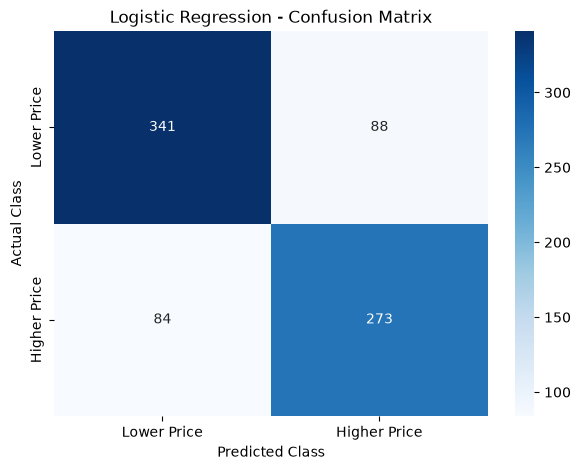

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Lower Price", "Higher Price"],
    yticklabels=["Lower Price", "Higher Price"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## 9. ROC Curve

The ROC curve shows the relationship between the True Positive Rate and False Positive Rate at different classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes the model's ability to distinguish between the two price classes.

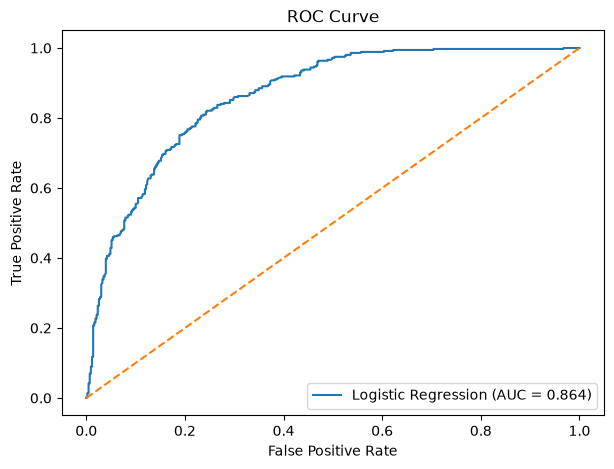

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 10. Actual vs Predicted Classes

The following table compares the actual class of each test observation with the class predicted by the Logistic Regression model.

In [10]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(20)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,0,0
4,1,0
5,1,1
6,1,1
7,0,0
8,0,0
9,1,0


## 11. Final Model Evaluation

The Logistic Regression model was evaluated using Accuracy, ROC-AUC, and classification metrics.

The final accuracy represents the percentage of correctly classified cars in the unseen test dataset.

The confusion matrix and classification report provide additional information about the model's performance on both price classes.

In [11]:
print("=" * 45)
print("FINAL LOGISTIC REGRESSION RESULTS")
print("=" * 45)

print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Lower Price", "Higher Price"]
))

FINAL LOGISTIC REGRESSION RESULTS
Accuracy : 0.7812
ROC-AUC  : 0.8645

Classification Report:
              precision    recall  f1-score   support

 Lower Price       0.80      0.79      0.80       429
Higher Price       0.76      0.76      0.76       357

    accuracy                           0.78       786
   macro avg       0.78      0.78      0.78       786
weighted avg       0.78      0.78      0.78       786



## 12. Final Conclusion

A Logistic Regression model was developed to classify used cars into lower-price and higher-price categories using vehicle characteristics.

The model was trained using a leakage-safe preprocessing pipeline that included numerical feature scaling and categorical feature encoding.

The model was evaluated on an unseen test set using Accuracy, Confusion Matrix, Classification Report, and ROC-AUC.

The final results provide a baseline classification model that can be further improved in future work by testing additional classification algorithms and hyperparameter tuning.

## Final Results

The Logistic Regression model achieved an accuracy of **78.12%** on the test dataset.

The model achieved a ROC-AUC score of **0.8645**, indicating good ability to distinguish between lower-priced and higher-priced cars.

The classification report shows similar performance across both classes:

- Lower Price: F1-score = **0.80**
- Higher Price: F1-score = **0.76**

Overall, Logistic Regression provides a solid baseline for the binary classification task. Further improvements could be explored through hyperparameter tuning and testing other classification algorithms.